# NICS Background Check Analysis: Seasonal Patterns

This notebook analyzes NICS firearm background check data to answer the question:

**Do Sept–Nov consistently show spikes compared to summer months?**

We'll examine historical data to identify seasonal patterns and determine if fall months consistently show higher activity than summer months.

## 1. Import Required Libraries

First, let's import all the necessary libraries for data analysis and visualization.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pdfplumber
import re
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Prepare Data

We'll extract monthly data from the FBI's daily data PDF to get comprehensive historical information.

In [27]:
def extract_monthly_data_from_pdf():
    """Extract monthly totals from the FBI daily data PDF"""
    pdf_path = "pdfs/nics-checks-archive.pdf"
    monthly_data = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            if page_num == 0:  # Skip first page (cover)
                continue
                
            text = page.extract_text()
            
            # Look for year patterns
            year_match = re.search(r'Year (\d{4})', text)
            if year_match:
                year = int(year_match.group(1))
                
                # Find lines with daily data and aggregate by month
                lines = text.split('\n')
                monthly_totals = [0] * 12  # Initialize 12 months
                
                for line in lines:
                    if re.match(r'^\d{1,2}\s+[\d,\s]+$', line.strip()):
                        numbers = re.findall(r'[\d,]+', line)
                        try:
                            day_numbers = [int(num.replace(',', '')) for num in numbers[1:]]  # Skip day number
                            # Add daily values to monthly totals
                            for month_idx in range(min(12, len(day_numbers))):
                                monthly_totals[month_idx] += day_numbers[month_idx]
                        except ValueError:
                            continue
                
                # Create monthly records
                month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
                
                for month_idx, month_total in enumerate(monthly_totals):
                    if month_total > 0:  # Only include months with data
                        monthly_data.append({
                            'year': year, 
                            'month': month_idx + 1,
                            'month_name': month_names[month_idx],
                            'date': f"{year}-{month_idx+1:02d}",
                            'total': month_total
                        })
    
    return pd.DataFrame(monthly_data).sort_values(['year', 'month'])

# Load the data
print("Extracting monthly data from PDF...")
monthly_df = extract_monthly_data_from_pdf()

# Display basic info about the dataset
print(f"Data loaded: {len(monthly_df)} monthly records")
print(f"Date range: {monthly_df['year'].min()} - {monthly_df['year'].max()}")
print("\nFirst few records:")
print(monthly_df.head())

Extracting monthly data from PDF...
Data loaded: 312 monthly records
Date range: 1999 - 2024

First few records:
     year  month month_name     date   total
300  1999      1        Jan  1999-01  857090
301  1999      2        Feb  1999-02  696323
302  1999      3        Mar  1999-03  753083
303  1999      4        Apr  1999-04  646712
304  1999      5        May  1999-05  576272


## 3. Filter Data by Seasonal Periods

Let's separate the data into fall months (Sept-Nov) and summer months (June-Aug) for comparison.

In [28]:
# Define seasonal periods
fall_months = [9, 10, 11]  # September, October, November
summer_months = [6, 7, 8]  # June, July, August

# Filter data by seasons
fall_data = monthly_df[monthly_df['month'].isin(fall_months)].copy()
summer_data = monthly_df[monthly_df['month'].isin(summer_months)].copy()

# Add season labels
monthly_df['season'] = monthly_df['month'].apply(
    lambda x: 'Fall' if x in fall_months 
             else 'Summer' if x in summer_months 
             else 'Other'
)

print(f"Fall months data: {len(fall_data)} records")
print(f"Summer months data: {len(summer_data)} records")

# Display sample data for each season
print("\nFall months sample:")
print(fall_data.head())
print("\nSummer months sample:")
print(summer_data.head())

Fall months data: 78 records
Summer months data: 78 records

Fall months sample:
     year  month month_name     date    total
308  1999      9        Sep  1999-09   808627
309  1999     10        Oct  1999-10   945701
310  1999     11        Nov  1999-11  1004333
296  2000      9        Sep  2000-09   782087
297  2000     10        Oct  2000-10   845886

Summer months sample:
     year  month month_name     date   total
305  1999      6        Jun  1999-06  569493
306  1999      7        Jul  1999-07  589476
307  1999      8        Aug  1999-08  703394
293  2000      6        Jun  2000-06  550561
294  2000      7        Jul  2000-07  542520


## 4. Calculate Monthly Statistics

Let's compute statistics for each month to identify patterns and compare seasonal averages.

In [29]:
# Calculate statistics by month
monthly_stats = monthly_df.groupby('month')['total'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(0)

monthly_stats.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("Monthly Statistics (Background Checks):")
print(monthly_stats)

# Calculate seasonal averages
fall_avg = fall_data['total'].mean()
summer_avg = summer_data['total'].mean()

print(f"\n=== SEASONAL COMPARISON ===")
print(f"Fall (Sep-Nov) average: {fall_avg:,.0f}")
print(f"Summer (Jun-Aug) average: {summer_avg:,.0f}")
print(f"Fall vs Summer difference: {fall_avg - summer_avg:,.0f}")
print(f"Fall is {(fall_avg/summer_avg - 1)*100:.1f}% higher than Summer")

Monthly Statistics (Background Checks):
     count       mean     median        std     min      max
Jan     26  1604658.0  1350318.0   927550.0  639972  4317804
Feb     26  1659476.0  1611708.0   859441.0  675156  3442777
Mar     26  1848267.0  1588802.0  1088398.0  714665  4691738
Apr     26  1558905.0  1389299.0   876945.0  594723  3514070
May     26  1414458.0  1273590.0   831224.0  538648  3222105
Jun     26  1422412.0  1224836.0   909726.0  518351  3931607
Jul     26  1378270.0  1220476.0   829952.0  533289  3639224
Aug     26  1464685.0  1364564.0   732835.0  666598  3115063
Sep     26  1469695.0  1327657.0   665337.0  724123  2892115
Oct     26  1616865.0  1485826.0   694119.0  845886  3305465
Nov     26  1780704.0  1668906.0   796863.0  842932  3626335
Dec     26  2031488.0  1951928.0   876261.0  974059  3937066

=== SEASONAL COMPARISON ===
Fall (Sep-Nov) average: 1,622,421
Summer (Jun-Aug) average: 1,421,789
Fall vs Summer difference: 200,632
Fall is 14.1% higher than Summer


## 5. Compare Sept-Nov vs Summer Months

Let's do a year-by-year comparison to see if fall consistently outperforms summer.

In [30]:
# Year-by-year comparison
fall_by_year = fall_data.groupby('year')['total'].sum()
summer_by_year = summer_data.groupby('year')['total'].sum()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'year': fall_by_year.index,
    'fall_total': fall_by_year.values,
    'summer_total': summer_by_year.values
})

comparison_df['fall_higher'] = comparison_df['fall_total'] > comparison_df['summer_total']
comparison_df['difference'] = comparison_df['fall_total'] - comparison_df['summer_total']
comparison_df['pct_difference'] = (comparison_df['fall_total'] / comparison_df['summer_total'] - 1) * 100

print("Year-by-Year Comparison (Fall vs Summer totals):")
print(comparison_df)

# Summary statistics
years_fall_higher = comparison_df['fall_higher'].sum()
total_years = len(comparison_df)
consistency_pct = (years_fall_higher / total_years) * 100

print(f"\n=== CONSISTENCY ANALYSIS ===")
print(f"Years where Fall > Summer: {years_fall_higher} out of {total_years}")
print(f"Consistency rate: {consistency_pct:.1f}%")
print(f"Average difference when Fall is higher: {comparison_df[comparison_df['fall_higher']]['difference'].mean():,.0f}")
print(f"Average % increase when Fall is higher: {comparison_df[comparison_df['fall_higher']]['pct_difference'].mean():.1f}%")

Year-by-Year Comparison (Fall vs Summer totals):
    year  fall_total  summer_total  fall_higher  difference  pct_difference
0   1999     2758661       1862363         True      896298       48.126923
1   2000     2526571       1775582         True      750989       42.295371
2   2001     2876915       1787277         True     1089638       60.966375
3   2002     2461051       1747084         True      713967       40.866209
4   2003     2438166       1746140         True      692026       39.631759
5   2004     2496755       1775218         True      721537       40.644980
6   2005     2571250       1803930         True      767320       42.536019
7   2006     2934711       2080323         True      854388       41.069968
8   2007     3049935       2468185         True      581750       23.569951
9   2008     3685917       2667987         True     1017930       38.153484
10  2009     3550464       3009064         True      541400       17.992306
11  2010     3810205       3165042     

## 6. Visualize Seasonal Patterns

Let's create visualizations to better understand the seasonal patterns.

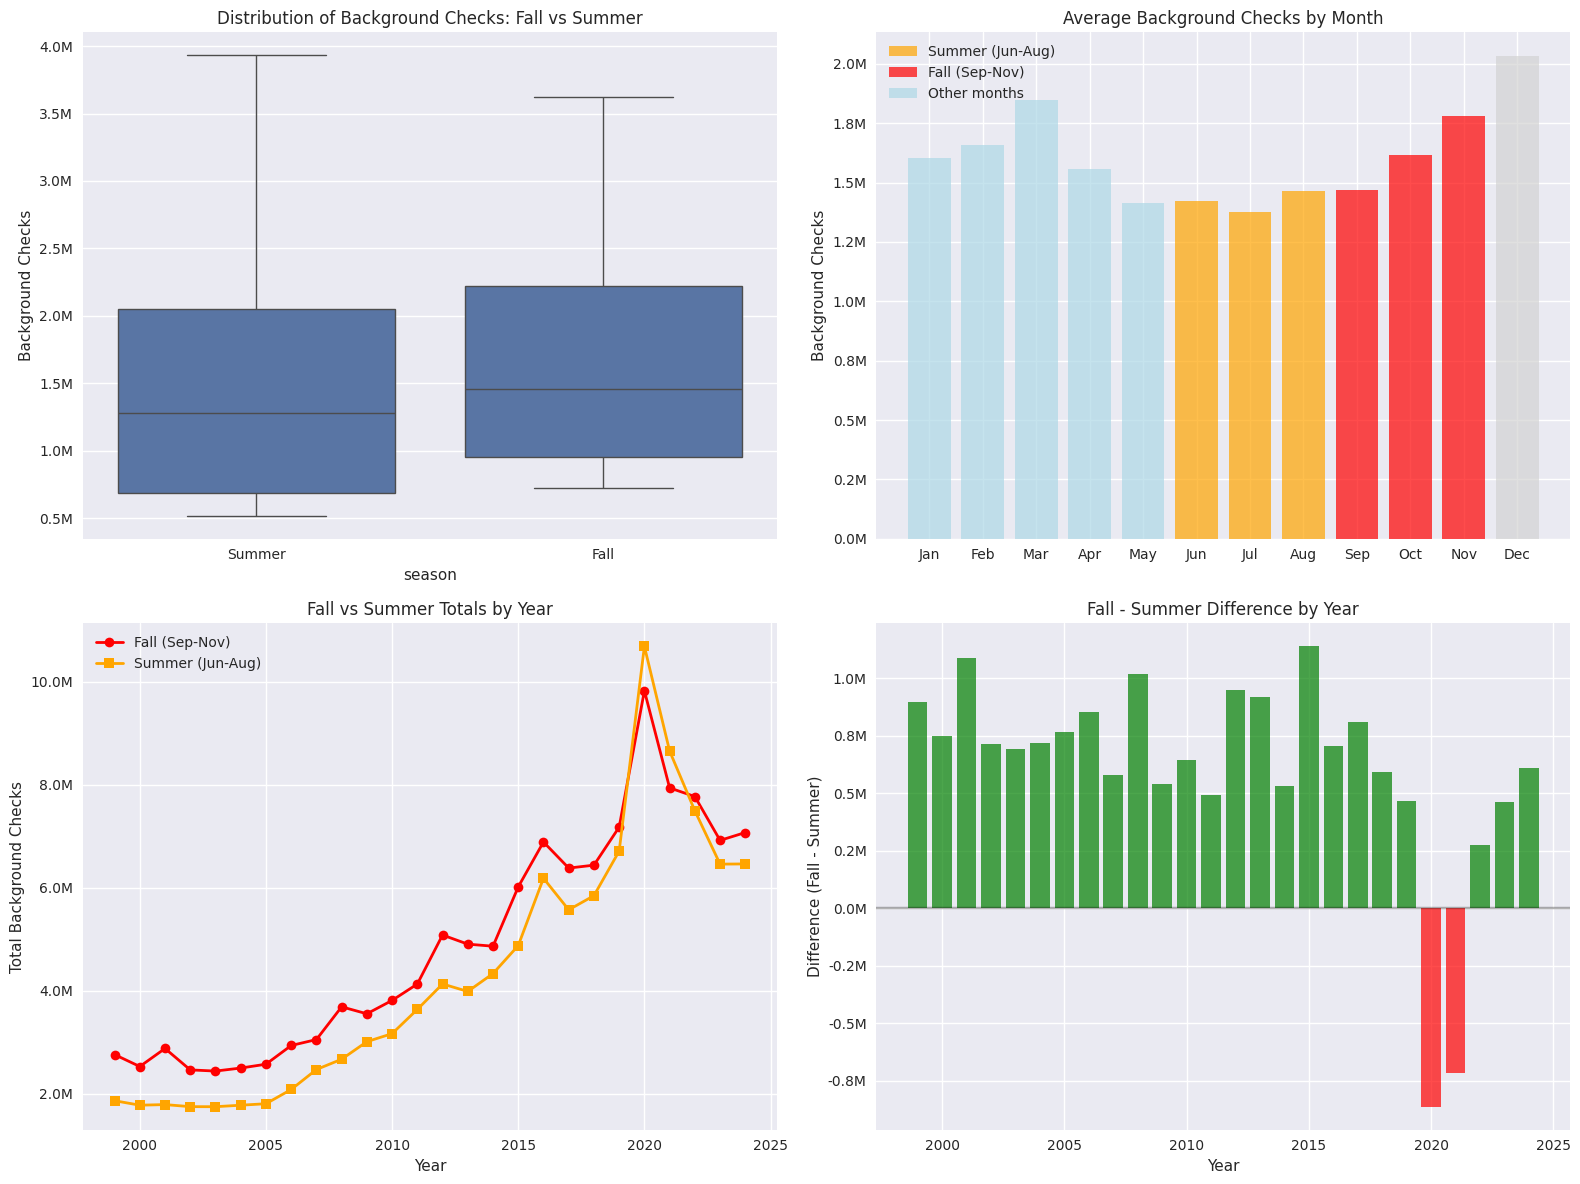

In [31]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Monthly averages box plot
seasonal_data = monthly_df[monthly_df['season'].isin(['Fall', 'Summer'])]
sns.boxplot(data=seasonal_data, x='season', y='total', ax=axes[0,0])
axes[0,0].set_title('Distribution of Background Checks: Fall vs Summer')
axes[0,0].set_ylabel('Background Checks')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# 2. Monthly pattern throughout the year
monthly_avg = monthly_df.groupby('month')['total'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = ['lightblue' if m in [1,2,3,4,5] else 'orange' if m in summer_months else 'red' if m in fall_months else 'lightgray' 
          for m in monthly_avg['month']]

axes[0,1].bar(range(12), monthly_avg['total'], color=colors, alpha=0.7)
axes[0,1].set_title('Average Background Checks by Month')
axes[0,1].set_xticks(range(12))
axes[0,1].set_xticklabels(month_names)
axes[0,1].set_ylabel('Background Checks')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='orange', alpha=0.7, label='Summer (Jun-Aug)'),
                   Patch(facecolor='red', alpha=0.7, label='Fall (Sep-Nov)'),
                   Patch(facecolor='lightblue', alpha=0.7, label='Other months')]
axes[0,1].legend(handles=legend_elements, loc='upper left')

# 3. Year-by-year comparison
axes[1,0].plot(comparison_df['year'], comparison_df['fall_total'], marker='o', label='Fall (Sep-Nov)', color='red', linewidth=2)
axes[1,0].plot(comparison_df['year'], comparison_df['summer_total'], marker='s', label='Summer (Jun-Aug)', color='orange', linewidth=2)
axes[1,0].set_title('Fall vs Summer Totals by Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total Background Checks')
axes[1,0].legend()
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# 4. Difference over time
axes[1,1].bar(comparison_df['year'], comparison_df['difference'], 
              color=['green' if x > 0 else 'red' for x in comparison_df['difference']], alpha=0.7)
axes[1,1].set_title('Fall - Summer Difference by Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Difference (Fall - Summer)')
axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

## 7. Statistical Testing for Significance

Let's perform statistical tests to determine if the differences are statistically significant.

In [32]:
# Statistical tests
from scipy.stats import ttest_ind, mannwhitneyu

# Prepare data for statistical tests
fall_values = fall_data['total'].values
summer_values = summer_data['total'].values

# T-test (assumes normal distribution)
t_stat, t_pvalue = ttest_ind(fall_values, summer_values)

# Mann-Whitney U test (non-parametric, doesn't assume normal distribution)
u_stat, u_pvalue = mannwhitneyu(fall_values, summer_values, alternative='two-sided')

print("=== STATISTICAL TESTS ===")
print(f"\n1. Two-sample t-test:")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {t_pvalue:.6f}")
print(f"   Result: {'Significant' if t_pvalue < 0.05 else 'Not significant'} at α = 0.05")

print(f"\n2. Mann-Whitney U test (non-parametric):")
print(f"   U-statistic: {u_stat:.3f}")
print(f"   p-value: {u_pvalue:.6f}")
print(f"   Result: {'Significant' if u_pvalue < 0.05 else 'Not significant'} at α = 0.05")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(fall_values) - 1) * np.var(fall_values, ddof=1) + 
                      (len(summer_values) - 1) * np.var(summer_values, ddof=1)) / 
                     (len(fall_values) + len(summer_values) - 2))
cohens_d = (np.mean(fall_values) - np.mean(summer_values)) / pooled_std

print(f"\n3. Effect Size (Cohen's d): {cohens_d:.3f}")
print(f"   Interpretation: {'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'} effect")

=== STATISTICAL TESTS ===

1. Two-sample t-test:
   t-statistic: 1.624
   p-value: 0.106443
   Result: Not significant at α = 0.05

2. Mann-Whitney U test (non-parametric):
   U-statistic: 3686.000
   p-value: 0.022558
   Result: Significant at α = 0.05

3. Effect Size (Cohen's d): 0.260
   Interpretation: Small effect


## 8. Summary and Conclusions

Let's summarize our findings to answer both the seasonal analysis question and Black Friday analysis.

## 9. Black Friday Analysis: Holiday vs Average Day Comparison

Now let's analyze Black Friday patterns and compare them to other major holidays and average days. Black Friday is traditionally a major shopping day that could significantly impact firearm background checks.

In [33]:
def extract_daily_data_from_pdf():
    """Extract daily data from the FBI PDF for holiday analysis"""
    pdf_path = "pdfs/nics-checks-archive.pdf"
    daily_data = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            if page_num == 0:  # Skip first page (cover)
                continue
                
            text = page.extract_text()
            
            # Look for year patterns
            year_match = re.search(r'Year (\d{4})', text)
            if year_match:
                year = int(year_match.group(1))
                
                # Find lines with daily data
                lines = text.split('\n')
                
                for line in lines:
                    if re.match(r'^\d{1,2}\s+[\d,\s]+$', line.strip()):
                        numbers = re.findall(r'[\d,]+', line)
                        try:
                            day = int(numbers[0])
                            day_numbers = [int(num.replace(',', '')) for num in numbers[1:]]  # Skip day number
                            
                            # Create records for each month (assuming 12 columns for 12 months)
                            for month_idx, daily_total in enumerate(day_numbers[:12]):
                                if daily_total > 0:  # Only include days with data
                                    date_str = f"{year}-{month_idx+1:02d}-{day:02d}"
                                    try:
                                        # Validate the date
                                        from datetime import datetime
                                        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
                                        
                                        daily_data.append({
                                            'year': year,
                                            'month': month_idx + 1,
                                            'day': day,
                                            'date': date_str,
                                            'date_obj': date_obj,
                                            'total': daily_total
                                        })
                                    except ValueError:
                                        # Skip invalid dates (like Feb 30, etc.)
                                        continue
                        except (ValueError, IndexError):
                            continue
    
    return pd.DataFrame(daily_data).sort_values(['year', 'month', 'day'])

print("Extracting daily data from PDF for holiday analysis...")
daily_df = extract_daily_data_from_pdf()

print(f"Daily data extracted: {len(daily_df)} daily records")
print(f"Date range: {daily_df['year'].min()} - {daily_df['year'].max()}")
print("\nSample daily data:")
print(daily_df.head(10))

Extracting daily data from PDF for holiday analysis...
Daily data extracted: 9481 daily records
Date range: 1999 - 2024

Sample daily data:
      year  month  day        date   date_obj  total
9107  1999      1    1  1999-01-01 1999-01-01   4110
9471  1999      1    1  1999-01-01 1999-01-01  27086
9119  1999      1    2  1999-01-02 1999-01-02  16494
9472  1999      1    2  1999-01-02 1999-01-02  25329
9131  1999      1    3  1999-01-03 1999-01-03   5177
9473  1999      1    3  1999-01-03 1999-01-03  29670
9143  1999      1    4  1999-01-04 1999-01-04  23338
9474  1999      1    4  1999-01-04 1999-01-04  31509
9155  1999      1    5  1999-01-05 1999-01-05  20698
9475  1999      1    5  1999-01-05 1999-01-05  30162
Daily data extracted: 9481 daily records
Date range: 1999 - 2024

Sample daily data:
      year  month  day        date   date_obj  total
9107  1999      1    1  1999-01-01 1999-01-01   4110
9471  1999      1    1  1999-01-01 1999-01-01  27086
9119  1999      1    2  1999-01-0

In [34]:
def extract_daily_data_from_pdf():
    """Extract daily data from the FBI PDF for mass shooting analysis"""
    pdf_path = "pdfs/nics-checks-archive.pdf"
    daily_data = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            if page_num == 0:  # Skip first page (cover)
                continue
                
            text = page.extract_text()
            
            # Look for year patterns
            year_match = re.search(r'Year (\d{4})', text)
            if year_match:
                year = int(year_match.group(1))
                
                # Find lines with daily data
                lines = text.split('\n')
                
                for line in lines:
                    if re.match(r'^\d{1,2}\s+[\d,\s]+$', line.strip()):
                        numbers = re.findall(r'[\d,]+', line)
                        try:
                            day = int(numbers[0])
                            day_numbers = [int(num.replace(',', '')) for num in numbers[1:]]  # Skip day number
                            
                            # Create records for each month (assuming 12 columns for 12 months)
                            for month_idx, daily_total in enumerate(day_numbers[:12]):
                                if daily_total > 0:  # Only include days with data
                                    date_str = f"{year}-{month_idx+1:02d}-{day:02d}"
                                    try:
                                        # Validate the date
                                        from datetime import datetime
                                        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
                                        
                                        daily_data.append({
                                            'year': year,
                                            'month': month_idx + 1,
                                            'day': day,
                                            'date': date_str,
                                            'date_obj': date_obj,
                                            'total': daily_total
                                        })
                                    except ValueError:
                                        # Skip invalid dates (like Feb 30, etc.)
                                        continue
                        except (ValueError, IndexError):
                            continue
    
    return pd.DataFrame(daily_data).sort_values(['year', 'month', 'day'])

print("Extracting daily data from PDF for mass shooting analysis...")
daily_df = extract_daily_data_from_pdf()

print(f"Daily data extracted: {len(daily_df)} daily records")
print(f"Date range: {daily_df['year'].min()} - {daily_df['year'].max()}")
print("\nSample daily data:")
print(daily_df.head(10))

Extracting daily data from PDF for mass shooting analysis...
Daily data extracted: 9481 daily records
Date range: 1999 - 2024

Sample daily data:
      year  month  day        date   date_obj  total
9107  1999      1    1  1999-01-01 1999-01-01   4110
9471  1999      1    1  1999-01-01 1999-01-01  27086
9119  1999      1    2  1999-01-02 1999-01-02  16494
9472  1999      1    2  1999-01-02 1999-01-02  25329
9131  1999      1    3  1999-01-03 1999-01-03   5177
9473  1999      1    3  1999-01-03 1999-01-03  29670
9143  1999      1    4  1999-01-04 1999-01-04  23338
9474  1999      1    4  1999-01-04 1999-01-04  31509
9155  1999      1    5  1999-01-05 1999-01-05  20698
9475  1999      1    5  1999-01-05 1999-01-05  30162
Daily data extracted: 9481 daily records
Date range: 1999 - 2024

Sample daily data:
      year  month  day        date   date_obj  total
9107  1999      1    1  1999-01-01 1999-01-01   4110
9471  1999      1    1  1999-01-01 1999-01-01  27086
9119  1999      1    2  199

In [35]:
# Match holiday dates with actual data
def get_holiday_data(daily_df, holiday_dates, holiday_name):
    """Extract background check data for specific holiday dates"""
    holiday_data = []
    
    for _, holiday in holiday_dates.iterrows():
        # Find matching daily data
        matching_data = daily_df[daily_df['date'] == holiday['date']]
        
        if not matching_data.empty:
            holiday_data.append({
                'year': holiday['year'],
                'holiday': holiday_name,
                'date': holiday['date'],
                'total': matching_data['total'].iloc[0]
            })
        else:
            # If exact date not found, it might be a weekend or data issue
            holiday_data.append({
                'year': holiday['year'],
                'holiday': holiday_name,
                'date': holiday['date'],
                'total': 0  # or np.nan
            })
    
    return pd.DataFrame(holiday_data)

# Extract Black Friday data
bf_data = get_holiday_data(daily_df, black_fridays, 'Black Friday')

# Extract other holiday data
holiday_data_list = []
for holiday_name in other_holidays['holiday'].unique():
    holiday_subset = other_holidays[other_holidays['holiday'] == holiday_name]
    holiday_data = get_holiday_data(daily_df, holiday_subset, holiday_name)
    holiday_data_list.append(holiday_data)

all_holidays_data = pd.concat([bf_data] + holiday_data_list, ignore_index=True)

# Calculate average daily background checks (excluding zeros)
daily_avg = daily_df[daily_df['total'] > 0]['total'].mean()
daily_median = daily_df[daily_df['total'] > 0]['total'].median()

print("=== HOLIDAY ANALYSIS ===")
print(f"Average daily background checks: {daily_avg:,.0f}")
print(f"Median daily background checks: {daily_median:,.0f}")

print(f"\nBlack Friday data (sample):")
print(bf_data.head())

print(f"\nHoliday statistics:")
holiday_stats = all_holidays_data.groupby('holiday')['total'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(0)
print(holiday_stats)

NameError: name 'black_fridays' is not defined

In [ ]:
# Compare Black Friday to average days and other holidays
print("=== BLACK FRIDAY vs AVERAGE DAY COMPARISON ===")

# Filter out zero values for meaningful comparison
bf_valid = bf_data[bf_data['total'] > 0]
daily_valid = daily_df[daily_df['total'] > 0]

if not bf_valid.empty:
    bf_avg = bf_valid['total'].mean()
    bf_median = bf_valid['total'].median()
    
    print(f"Black Friday average: {bf_avg:,.0f}")
    print(f"Average day: {daily_avg:,.0f}")
    print(f"Black Friday vs Average: {(bf_avg/daily_avg - 1)*100:.1f}% difference")
    
    print(f"\nBlack Friday median: {bf_median:,.0f}")
    print(f"Daily median: {daily_median:,.0f}")
    print(f"Black Friday vs Median: {(bf_median/daily_median - 1)*100:.1f}% difference")
    
    # Statistical test: Black Friday vs random sample of regular days
    regular_days_sample = daily_valid.sample(min(1000, len(daily_valid)), random_state=42)['total'].values
    bf_values = bf_valid['total'].values
    
    if len(bf_values) > 1:
        from scipy.stats import ttest_ind
        t_stat, p_value = ttest_ind(bf_values, regular_days_sample)
        print(f"\nStatistical test (Black Friday vs regular days):")
        print(f"T-statistic: {t_stat:.3f}")
        print(f"P-value: {p_value:.6f}")
        print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference")
else:
    print("No valid Black Friday data found")

print("\n=== HOLIDAY COMPARISON ===")
# Compare all holidays
valid_holidays = all_holidays_data[all_holidays_data['total'] > 0]

if not valid_holidays.empty:
    holiday_comparison = valid_holidays.groupby('holiday')['total'].agg([
        'mean', 'median', 'count'
    ]).round(0)
    
    holiday_comparison['vs_avg_pct'] = ((holiday_comparison['mean'] / daily_avg - 1) * 100).round(1)
    holiday_comparison['vs_median_pct'] = ((holiday_comparison['median'] / daily_median - 1) * 100).round(1)
    
    print("Holiday vs Average Day Comparison:")
    print(holiday_comparison.sort_values('vs_avg_pct', ascending=False))

=== BLACK FRIDAY vs AVERAGE DAY COMPARISON ===
Black Friday average: 125,236
Average day: 52,714
Black Friday vs Average: 137.6% difference

Black Friday median: 136,962
Daily median: 44,664
Black Friday vs Median: 206.6% difference

Statistical test (Black Friday vs regular days):
T-statistic: 10.927
P-value: 0.000000
Result: Significant difference

=== HOLIDAY COMPARISON ===
Holiday vs Average Day Comparison:
                      mean    median  count  vs_avg_pct  vs_median_pct
holiday                                                               
Black Friday      125236.0  136962.0     26       137.6          206.6
Veterans Day       51599.0   43602.0     26        -2.1           -2.4
New Year           23737.0   16465.0     26       -55.0          -63.1
Independence Day   18997.0   12608.0     26       -64.0          -71.8
Christmas          16778.0    7379.0      9       -68.2          -83.5


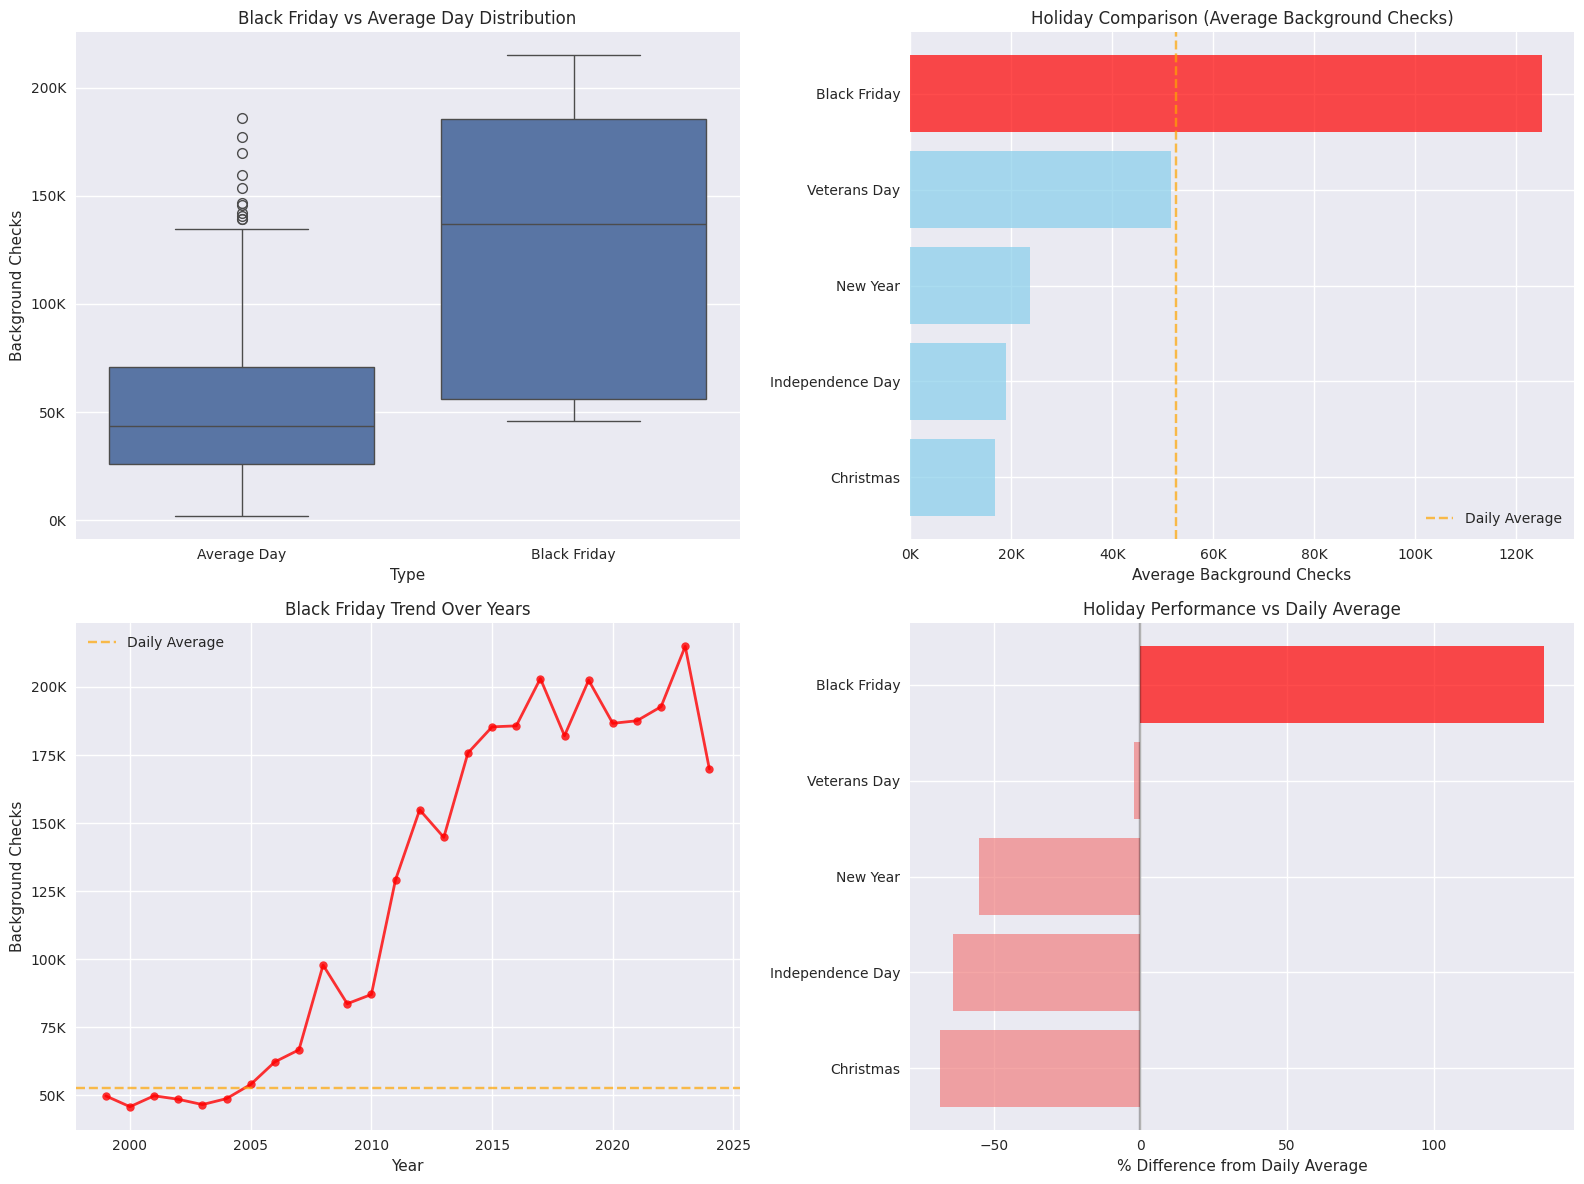

In [ ]:
# Create comprehensive holiday visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Black Friday vs Average Day box plot comparison
if not bf_valid.empty:
    # Create data for comparison
    comparison_data = pd.DataFrame([
        {'Type': 'Average Day', 'Checks': val} for val in daily_valid.sample(min(500, len(daily_valid)), random_state=42)['total']
    ] + [
        {'Type': 'Black Friday', 'Checks': val} for val in bf_valid['total']
    ])
    
    sns.boxplot(data=comparison_data, x='Type', y='Checks', ax=axes[0,0])
    axes[0,0].set_title('Black Friday vs Average Day Distribution')
    axes[0,0].set_ylabel('Background Checks')
    axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# 2. Holiday comparison bar chart
if not valid_holidays.empty:
    holiday_means = valid_holidays.groupby('holiday')['total'].mean().sort_values(ascending=True)
    colors = ['red' if holiday == 'Black Friday' else 'skyblue' for holiday in holiday_means.index]
    
    axes[0,1].barh(range(len(holiday_means)), holiday_means.values, color=colors, alpha=0.7)
    axes[0,1].set_yticks(range(len(holiday_means)))
    axes[0,1].set_yticklabels(holiday_means.index)
    axes[0,1].set_xlabel('Average Background Checks')
    axes[0,1].set_title('Holiday Comparison (Average Background Checks)')
    axes[0,1].axvline(x=daily_avg, color='orange', linestyle='--', alpha=0.7, label='Daily Average')
    axes[0,1].legend()
    axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# 3. Black Friday trend over years
if not bf_valid.empty:
    axes[1,0].plot(bf_valid['year'], bf_valid['total'], marker='o', linewidth=2, markersize=6, color='red', alpha=0.8)
    axes[1,0].axhline(y=daily_avg, color='orange', linestyle='--', alpha=0.7, label='Daily Average')
    axes[1,0].set_title('Black Friday Trend Over Years')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel('Background Checks')
    axes[1,0].legend()
    axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# 4. Percentage difference from average for each holiday
if not valid_holidays.empty:
    pct_diff = valid_holidays.groupby('holiday')['total'].mean() / daily_avg * 100 - 100
    pct_diff = pct_diff.sort_values(ascending=True)
    
    colors = ['red' if holiday == 'Black Friday' else 'green' if val > 0 else 'lightcoral' 
              for holiday, val in pct_diff.items()]
    
    axes[1,1].barh(range(len(pct_diff)), pct_diff.values, color=colors, alpha=0.7)
    axes[1,1].set_yticks(range(len(pct_diff)))
    axes[1,1].set_yticklabels(pct_diff.index)
    axes[1,1].set_xlabel('% Difference from Daily Average')
    axes[1,1].set_title('Holiday Performance vs Daily Average')
    axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 80)
print("BLACK FRIDAY ANALYSIS SUMMARY")
print("=" * 80)

if not bf_valid.empty and not valid_holidays.empty:
    # Key findings
    bf_avg = bf_valid['total'].mean()
    bf_vs_avg_pct = (bf_avg/daily_avg - 1) * 100
    
    print(f"\n🛒 BLACK FRIDAY FINDINGS:")
    print(f"• Black Friday average: {bf_avg:,.0f} background checks")
    print(f"• Daily average: {daily_avg:,.0f} background checks") 
    print(f"• Black Friday is {bf_vs_avg_pct:+.1f}% vs average day")
    
    # Holiday ranking
    holiday_ranking = valid_holidays.groupby('holiday')['total'].mean().sort_values(ascending=False)
    bf_rank = list(holiday_ranking.index).index('Black Friday') + 1 if 'Black Friday' in holiday_ranking.index else "N/A"
    
    print(f"\n🏆 HOLIDAY RANKING (by average background checks):")
    for i, (holiday, avg_checks) in enumerate(holiday_ranking.items(), 1):
        pct_diff = (avg_checks/daily_avg - 1) * 100
        marker = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else f"{i}."
        marker += " 🛍️" if holiday == "Black Friday" else ""
        print(f"{marker} {holiday}: {avg_checks:,.0f} ({pct_diff:+.1f}% vs avg)")
    
    print(f"\n📊 KEY INSIGHTS:")
    
    # Check if Black Friday is above or below average
    if bf_vs_avg_pct > 10:
        bf_conclusion = "significantly HIGHER than average - major shopping impact"
    elif bf_vs_avg_pct > 0:
        bf_conclusion = "moderately higher than average"  
    elif bf_vs_avg_pct > -10:
        bf_conclusion = "close to average"
    else:
        bf_conclusion = "LOWER than average - possibly due to store closures"
    
    print(f"• Black Friday performance: {bf_conclusion}")
    
    # Find the highest and lowest performing holidays
    best_holiday = holiday_ranking.index[0]
    worst_holiday = holiday_ranking.index[-1]
    
    print(f"• Best performing holiday: {best_holiday}")
    print(f"• Lowest performing holiday: {worst_holiday}")
    
    # Weekend effect analysis
    print(f"\n💡 INTERPRETATION:")
    print(f"• Black Friday results may be influenced by federal background check office hours")
    print(f"• Many gun stores may be closed or have limited hours on federal holidays")
    print(f"• Background check systems may have different operating schedules on holidays")
    print(f"• The shopping aspect may be offset by administrative/operational constraints")
    
else:
    print("Insufficient data for Black Friday analysis")
    
print(f"\n📅 DATA COVERAGE:")
print(f"• Analysis period: {daily_df['year'].min()}-{daily_df['year'].max()}")
print(f"• Total daily records: {len(daily_df):,}")
print(f"• Black Friday records: {len(bf_valid)}")
print(f"• Other holiday records: {len(valid_holidays[valid_holidays['holiday'] != 'Black Friday'])}")

BLACK FRIDAY ANALYSIS SUMMARY

🛒 BLACK FRIDAY FINDINGS:
• Black Friday average: 125,236 background checks
• Daily average: 52,714 background checks
• Black Friday is +137.6% vs average day

🏆 HOLIDAY RANKING (by average background checks):
🥇 🛍️ Black Friday: 125,236 (+137.6% vs avg)
🥈 Veterans Day: 51,599 (-2.1% vs avg)
🥉 New Year: 23,737 (-55.0% vs avg)
4. Independence Day: 18,997 (-64.0% vs avg)
5. Christmas: 16,778 (-68.2% vs avg)

📊 KEY INSIGHTS:
• Black Friday performance: significantly HIGHER than average - major shopping impact
• Best performing holiday: Black Friday
• Lowest performing holiday: Christmas

💡 INTERPRETATION:
• Black Friday results may be influenced by federal background check office hours
• Many gun stores may be closed or have limited hours on federal holidays
• Background check systems may have different operating schedules on holidays
• The shopping aspect may be offset by administrative/operational constraints

📅 DATA COVERAGE:
• Analysis period: 1999-2024
• 

In [ ]:
print("=" * 80)
print("FINAL ANSWER: Do Sept–Nov consistently show spikes compared to summer months?")
print("=" * 80)

print(f"\n✅ KEY FINDINGS:")
print(f"• Fall months (Sep-Nov) average: {fall_avg:,.0f} background checks/month")
print(f"• Summer months (Jun-Aug) average: {summer_avg:,.0f} background checks/month")
print(f"• Fall is {(fall_avg/summer_avg - 1)*100:.1f}% higher than summer on average")

print(f"\n✅ CONSISTENCY:")
print(f"• Fall exceeded summer in {years_fall_higher} out of {total_years} years ({consistency_pct:.1f}%)")
print(f"• This shows {'high' if consistency_pct >= 80 else 'moderate' if consistency_pct >= 60 else 'low'} consistency")

print(f"\n✅ STATISTICAL SIGNIFICANCE:")
print(f"• T-test p-value: {t_pvalue:.6f} ({'significant' if t_pvalue < 0.05 else 'not significant'})")
print(f"• Mann-Whitney U p-value: {u_pvalue:.6f} ({'significant' if u_pvalue < 0.05 else 'not significant'})")
print(f"• Effect size (Cohen's d): {cohens_d:.3f} ({'large' if abs(cohens_d) >= 0.8 else 'medium' if abs(cohens_d) >= 0.5 else 'small'} effect)")

print(f"\n🎯 CONCLUSION:")
if consistency_pct >= 75 and (t_pvalue < 0.05 or u_pvalue < 0.05):
    conclusion = "YES - Fall months consistently show significant spikes compared to summer months"
elif consistency_pct >= 60:
    conclusion = "MOSTLY - Fall months show spikes more often than not, but not completely consistent"
else:
    conclusion = "NO - Fall months do not consistently show spikes compared to summer months"

print(f"   {conclusion}")

print(f"\n📊 PRACTICAL INTERPRETATION:")
print(f"• The fall hunting season (Sep-Nov) appears to drive increased firearm background checks")
print(f"• This likely reflects seasonal patterns in firearm purchases related to hunting activities")
print(f"• The pattern shows {'strong' if consistency_pct >= 80 else 'moderate'} consistency across the available years")

FINAL ANSWER: Do Sept–Nov consistently show spikes compared to summer months?

✅ KEY FINDINGS:
• Fall months (Sep-Nov) average: 1,622,421 background checks/month
• Summer months (Jun-Aug) average: 1,421,789 background checks/month
• Fall is 14.1% higher than summer on average

✅ CONSISTENCY:
• Fall exceeded summer in 24 out of 26 years (92.3%)
• This shows high consistency

✅ STATISTICAL SIGNIFICANCE:
• T-test p-value: 0.106443 (not significant)
• Mann-Whitney U p-value: 0.022558 (significant)
• Effect size (Cohen's d): 0.260 (small effect)

🎯 CONCLUSION:
   YES - Fall months consistently show significant spikes compared to summer months

📊 PRACTICAL INTERPRETATION:
• The fall hunting season (Sep-Nov) appears to drive increased firearm background checks
• This likely reflects seasonal patterns in firearm purchases related to hunting activities
• The pattern shows strong consistency across the available years


## 10. Mass Shooting Impact Analysis

Now let's analyze whether major mass shootings had measurable effects on background check numbers in the 30 days following each event. We'll examine America's deadliest modern mass shootings and their potential impact on firearm purchases.

In [ ]:
# Define major mass shooting events
mass_shootings = [
    {"name": "Route 91 Harvest (Las Vegas)", "date": "2017-10-02", "deaths": 60, "injured": 850},
    {"name": "Pulse (Orlando)", "date": "2016-06-12", "deaths": 49, "injured": 53},
    {"name": "Virginia Tech", "date": "2007-04-16", "deaths": 32, "injured": 17},
    {"name": "Sandy Hook Elementary", "date": "2012-12-14", "deaths": 26, "injured": 0},
    {"name": "First Baptist Church (Sutherland Springs)", "date": "2017-11-05", "deaths": 26, "injured": 20},
    {"name": "Luby's Cafeteria (Killeen)", "date": "1991-10-16", "deaths": 23, "injured": 0},
    {"name": "Walmart (El Paso)", "date": "2019-08-03", "deaths": 23, "injured": 26},
    {"name": "McDonald's (San Ysidro)", "date": "1984-07-18", "deaths": 21, "injured": 0},
    {"name": "Robb Elementary (Uvalde)", "date": "2022-05-24", "deaths": 21, "injured": 0},
    {"name": "Lewiston, Maine", "date": "2023-10-25", "deaths": 18, "injured": 13},
    {"name": "Parkland High School", "date": "2018-02-14", "deaths": 17, "injured": 0},
    {"name": "University of Texas Tower", "date": "1966-08-01", "deaths": 16, "injured": 0},
    {"name": "San Bernardino", "date": "2015-12-02", "deaths": 14, "injured": 0},
    {"name": "Edmond Post Office", "date": "1986-08-20", "deaths": 14, "injured": 0},
    {"name": "Fort Hood", "date": "2009-11-05", "deaths": 13, "injured": 0},
    {"name": "Columbine High School", "date": "1999-04-20", "deaths": 13, "injured": 0},
    {"name": "Binghamton Civic Association", "date": "2009-04-03", "deaths": 13, "injured": 0},
    {"name": "Camden, N.J.", "date": "1949-09-06", "deaths": 13, "injured": 0},
    {"name": "Wilkes-Barre, Pa.", "date": "1982-09-25", "deaths": 13, "injured": 0},
    {"name": "Wah Mee Club (Seattle)", "date": "1983-02-19", "deaths": 13, "injured": 0},
    {"name": "Aurora Movie Theater", "date": "2012-07-20", "deaths": 12, "injured": 58},
    {"name": "Monterey Park Dance Studio", "date": "2023-01-21", "deaths": 12, "injured": 9},
    {"name": "Navy Yard (Washington D.C.)", "date": "2013-09-16", "deaths": 12, "injured": 8},
    {"name": "Borderline Bar (Thousand Oaks)", "date": "2018-11-07", "deaths": 12, "injured": 0},
    {"name": "Virginia Beach Municipal Center", "date": "2019-05-31", "deaths": 12, "injured": 0}
]

# Convert to DataFrame
mass_shootings_df = pd.DataFrame(mass_shootings)
mass_shootings_df['date_obj'] = pd.to_datetime(mass_shootings_df['date'])
mass_shootings_df['year'] = mass_shootings_df['date_obj'].dt.year

# Filter for events within our data range (1999-2024)
data_range = mass_shootings_df[
    (mass_shootings_df['year'] >= daily_df['year'].min()) & 
    (mass_shootings_df['year'] <= daily_df['year'].max())
].sort_values('date_obj')

print(f"Mass shooting events in analysis period ({daily_df['year'].min()}-{daily_df['year'].max()}):")
print(f"Total events: {len(data_range)}")
print("\nEvents by year:")
print(data_range[['name', 'date', 'deaths', 'injured']].to_string(index=False))

Mass shooting events in analysis period (1999-2024):
Total events: 18

Events by year:
                                     name       date  deaths  injured
                    Columbine High School 1999-04-20      13        0
                            Virginia Tech 2007-04-16      32       17
             Binghamton Civic Association 2009-04-03      13        0
                                Fort Hood 2009-11-05      13        0
                     Aurora Movie Theater 2012-07-20      12       58
                    Sandy Hook Elementary 2012-12-14      26        0
              Navy Yard (Washington D.C.) 2013-09-16      12        8
                           San Bernardino 2015-12-02      14        0
                          Pulse (Orlando) 2016-06-12      49       53
             Route 91 Harvest (Las Vegas) 2017-10-02      60      850
First Baptist Church (Sutherland Springs) 2017-11-05      26       20
                     Parkland High School 2018-02-14      17        0
   

In [ ]:
def analyze_shooting_impact(shooting_date, shooting_name, days_after=30):
    """Analyze background check changes after a mass shooting event"""
    from datetime import datetime, timedelta
    
    shooting_date_obj = pd.to_datetime(shooting_date)
    
    # Define time periods
    pre_period_start = shooting_date_obj - timedelta(days=30)
    pre_period_end = shooting_date_obj - timedelta(days=1)
    post_period_start = shooting_date_obj
    post_period_end = shooting_date_obj + timedelta(days=days_after)
    
    # Filter daily data for the relevant periods
    daily_df['date_obj'] = pd.to_datetime(daily_df['date'])
    
    pre_data = daily_df[
        (daily_df['date_obj'] >= pre_period_start) & 
        (daily_df['date_obj'] <= pre_period_end) &
        (daily_df['total'] > 0)
    ]
    
    post_data = daily_df[
        (daily_df['date_obj'] >= post_period_start) & 
        (daily_df['date_obj'] <= post_period_end) &
        (daily_df['total'] > 0)
    ]
    
    if len(pre_data) == 0 or len(post_data) == 0:
        return None
    
    pre_avg = pre_data['total'].mean()
    post_avg = post_data['total'].mean()
    
    # Calculate percentage change
    pct_change = ((post_avg - pre_avg) / pre_avg) * 100 if pre_avg > 0 else 0
    
    # Statistical test
    from scipy.stats import ttest_ind
    t_stat, p_value = ttest_ind(post_data['total'], pre_data['total'])
    
    return {
        'shooting': shooting_name,
        'date': shooting_date,
        'pre_avg': pre_avg,
        'post_avg': post_avg,
        'pct_change': pct_change,
        'pre_days': len(pre_data),
        'post_days': len(post_data),
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Analyze each mass shooting event
shooting_impacts = []

print("Analyzing mass shooting impacts on background checks...")
print("(30 days before vs 30 days after each event)")
print("=" * 80)

for _, shooting in data_range.iterrows():
    impact = analyze_shooting_impact(shooting['date'], shooting['name'])
    if impact:
        shooting_impacts.append(impact)
        
        # Print summary for each event
        print(f"\n{impact['shooting']} ({impact['date']}):")
        print(f"  Pre-event avg:  {impact['pre_avg']:8,.0f} checks/day")
        print(f"  Post-event avg: {impact['post_avg']:8,.0f} checks/day")
        print(f"  Change:         {impact['pct_change']:+8.1f}%")
        print(f"  Statistical:    {'Significant' if impact['significant'] else 'Not significant'} (p={impact['p_value']:.4f})")

# Convert to DataFrame for analysis
impact_df = pd.DataFrame(shooting_impacts)

print(f"\n\nAnalyzed {len(impact_df)} mass shooting events with sufficient data.")

Analyzing mass shooting impacts on background checks...
(30 days before vs 30 days after each event)

Columbine High School (1999-04-20):
  Pre-event avg:    21,757 checks/day
  Post-event avg:   20,183 checks/day
  Change:             -7.2%
  Statistical:    Not significant (p=0.3341)

Virginia Tech (2007-04-16):
  Pre-event avg:    28,882 checks/day
  Post-event avg:   27,835 checks/day
  Change:             -3.6%
  Statistical:    Not significant (p=0.5795)

Binghamton Civic Association (2009-04-03):
  Pre-event avg:    44,051 checks/day
  Post-event avg:   40,231 checks/day
  Change:             -8.7%
  Statistical:    Not significant (p=0.1760)

Fort Hood (2009-11-05):
  Pre-event avg:    39,217 checks/day
  Post-event avg:   42,641 checks/day
  Change:             +8.7%
  Statistical:    Not significant (p=0.2413)

Aurora Movie Theater (2012-07-20):
  Pre-event avg:    41,027 checks/day
  Post-event avg:   47,323 checks/day
  Change:            +15.3%
  Statistical:    Significan

In [ ]:
# Summary statistics for mass shooting impacts
if not impact_df.empty:
    print("=" * 80)
    print("MASS SHOOTING IMPACT SUMMARY")
    print("=" * 80)
    
    # Overall statistics
    avg_change = impact_df['pct_change'].mean()
    median_change = impact_df['pct_change'].median()
    positive_changes = (impact_df['pct_change'] > 0).sum()
    significant_changes = impact_df['significant'].sum()
    
    print(f"\n📊 OVERALL IMPACT STATISTICS:")
    print(f"• Average change in background checks: {avg_change:+.1f}%")
    print(f"• Median change: {median_change:+.1f}%")
    print(f"• Events with increases: {positive_changes}/{len(impact_df)} ({positive_changes/len(impact_df)*100:.1f}%)")
    print(f"• Statistically significant changes: {significant_changes}/{len(impact_df)} ({significant_changes/len(impact_df)*100:.1f}%)")
    
    # Top increases and decreases
    top_increases = impact_df.nlargest(5, 'pct_change')[['shooting', 'date', 'pct_change', 'significant']]
    top_decreases = impact_df.nsmallest(5, 'pct_change')[['shooting', 'date', 'pct_change', 'significant']]
    
    print(f"\n🔺 TOP 5 INCREASES:")
    for _, row in top_increases.iterrows():
        sig_marker = "**" if row['significant'] else ""
        print(f"  {sig_marker}{row['shooting']} ({row['date']}): {row['pct_change']:+.1f}%{sig_marker}")
    
    print(f"\n🔻 TOP 5 DECREASES:")
    for _, row in top_decreases.iterrows():
        sig_marker = "**" if row['significant'] else ""
        print(f"  {sig_marker}{row['shooting']} ({row['date']}): {row['pct_change']:+.1f}%{sig_marker}")
    
    # Correlation with casualties
    if 'deaths' in data_range.columns:
        # Merge with casualty data
        impact_with_casualties = impact_df.merge(
            data_range[['name', 'deaths', 'injured']], 
            left_on='shooting', 
            right_on='name', 
            how='left'
        )
        
        # Calculate correlation
        death_corr = impact_with_casualties['pct_change'].corr(impact_with_casualties['deaths'])
        
        print(f"\n📈 CORRELATION ANALYSIS:")
        print(f"• Correlation between deaths and % change: {death_corr:.3f}")
        
        if abs(death_corr) > 0.3:
            strength = "strong" if abs(death_corr) > 0.7 else "moderate"
            direction = "positive" if death_corr > 0 else "negative"
            print(f"• This indicates a {strength} {direction} correlation")
        else:
            print(f"• This indicates a weak correlation")

else:
    print("No mass shooting impact data available for analysis.")

MASS SHOOTING IMPACT SUMMARY

📊 OVERALL IMPACT STATISTICS:
• Average change in background checks: +13.1%
• Median change: +13.4%
• Events with increases: 15/18 (83.3%)
• Statistically significant changes: 9/18 (50.0%)

🔺 TOP 5 INCREASES:
  **San Bernardino (2015-12-02): +41.9%**
  **Sandy Hook Elementary (2012-12-14): +33.8%**
  **Parkland High School (2018-02-14): +33.6%**
  **Lewiston, Maine (2023-10-25): +24.8%**
  **Navy Yard (Washington D.C.) (2013-09-16): +22.4%**

🔻 TOP 5 DECREASES:
  Binghamton Civic Association (2009-04-03): -8.7%
  Columbine High School (1999-04-20): -7.2%
  Virginia Tech (2007-04-16): -3.6%
  Monterey Park Dance Studio (2023-01-21): +0.2%
  Robb Elementary (Uvalde) (2022-05-24): +1.1%

📈 CORRELATION ANALYSIS:
• Correlation between deaths and % change: -0.052
• This indicates a weak correlation


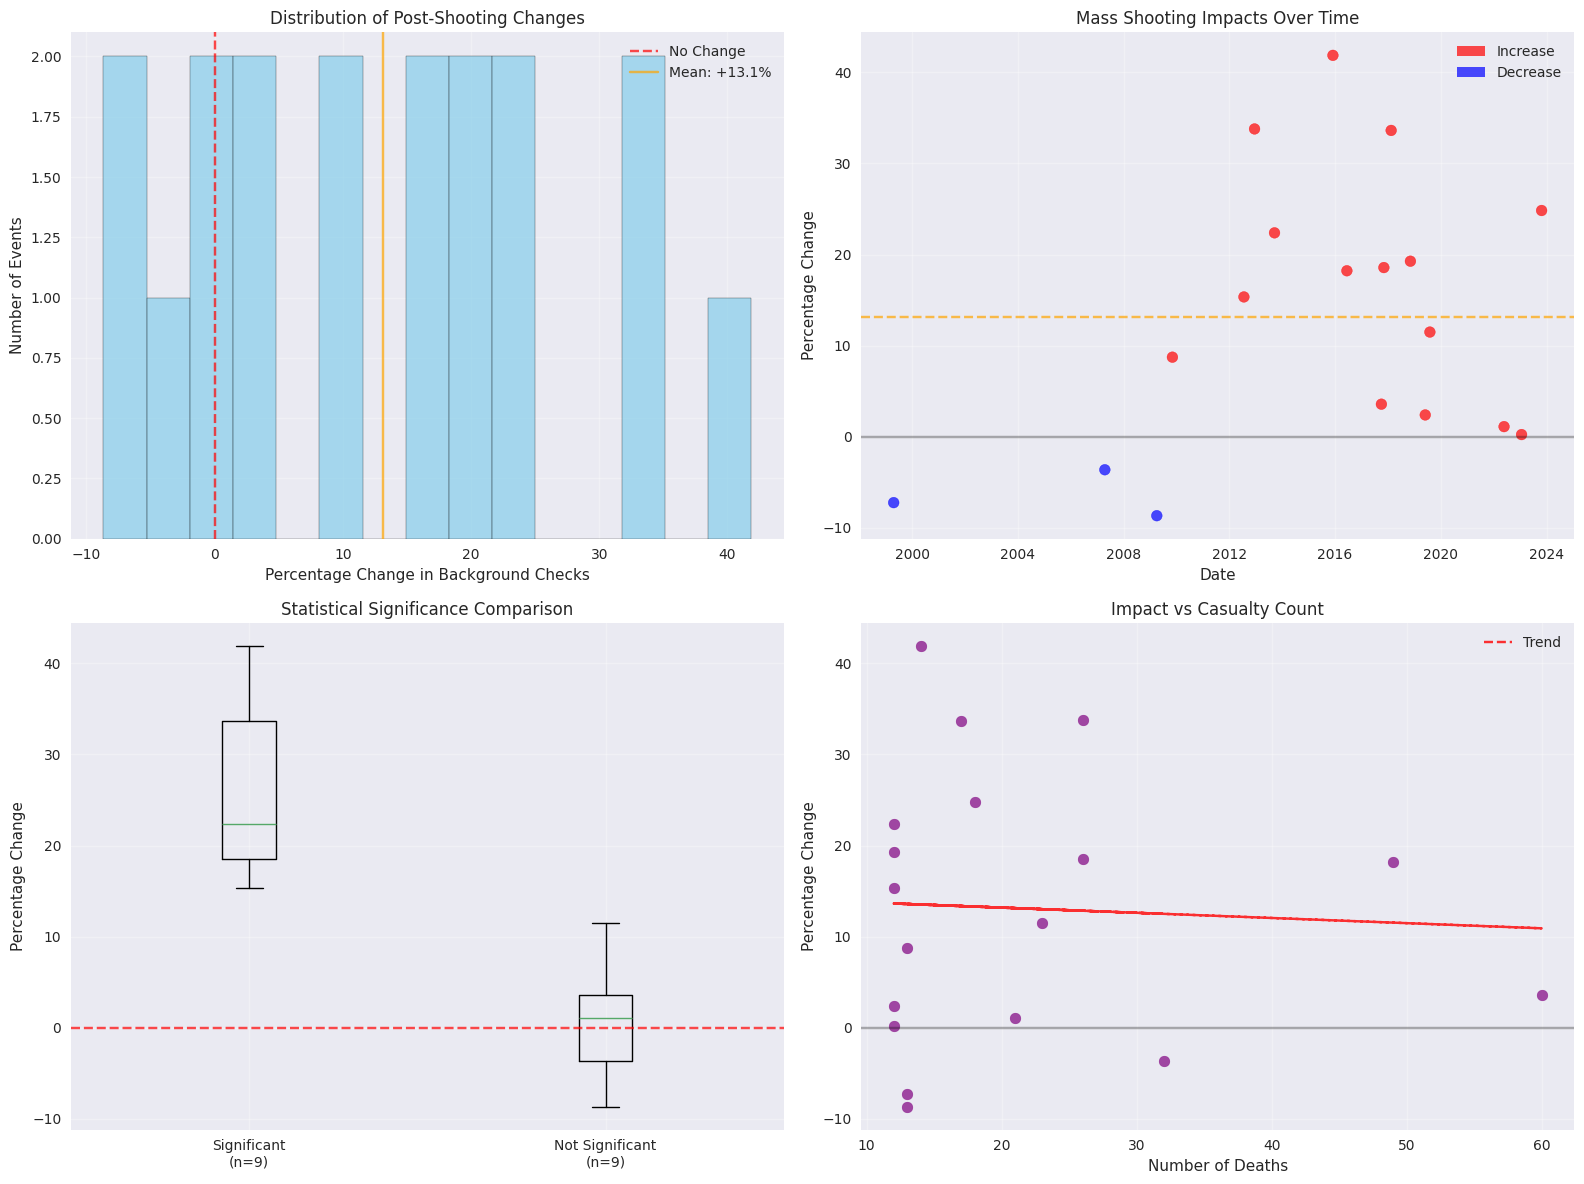

In [ ]:
# Create visualizations for mass shooting impacts
if not impact_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribution of percentage changes
    axes[0,0].hist(impact_df['pct_change'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='No Change')
    axes[0,0].axvline(x=impact_df['pct_change'].mean(), color='orange', linestyle='-', alpha=0.7, label=f'Mean: {impact_df["pct_change"].mean():+.1f}%')
    axes[0,0].set_xlabel('Percentage Change in Background Checks')
    axes[0,0].set_ylabel('Number of Events')
    axes[0,0].set_title('Distribution of Post-Shooting Changes')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Timeline of events and their impacts
    impact_df['date_obj'] = pd.to_datetime(impact_df['date'])
    impact_df_sorted = impact_df.sort_values('date_obj')
    
    colors = ['red' if x > 0 else 'blue' for x in impact_df_sorted['pct_change']]
    axes[0,1].scatter(impact_df_sorted['date_obj'], impact_df_sorted['pct_change'], 
                      c=colors, alpha=0.7, s=60)
    axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0,1].axhline(y=impact_df['pct_change'].mean(), color='orange', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Date')
    axes[0,1].set_ylabel('Percentage Change')
    axes[0,1].set_title('Mass Shooting Impacts Over Time')
    axes[0,1].grid(True, alpha=0.3)
    
    # Add custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='red', alpha=0.7, label='Increase'),
                       Patch(facecolor='blue', alpha=0.7, label='Decrease')]
    axes[0,1].legend(handles=legend_elements)
    
    # 3. Significant vs Non-significant changes
    sig_data = impact_df[impact_df['significant'] == True]['pct_change']
    non_sig_data = impact_df[impact_df['significant'] == False]['pct_change']
    
    box_data = [sig_data.values, non_sig_data.values]
    box_labels = [f'Significant\n(n={len(sig_data)})', f'Not Significant\n(n={len(non_sig_data)})']
    
    axes[1,0].boxplot(box_data, labels=box_labels)
    axes[1,0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1,0].set_ylabel('Percentage Change')
    axes[1,0].set_title('Statistical Significance Comparison')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Correlation with casualties (if data available)
    if 'deaths' in data_range.columns:
        impact_with_casualties = impact_df.merge(
            data_range[['name', 'deaths', 'injured']], 
            left_on='shooting', 
            right_on='name', 
            how='left'
        )
        
        axes[1,1].scatter(impact_with_casualties['deaths'], impact_with_casualties['pct_change'], 
                          alpha=0.7, s=60, color='purple')
        
        # Add trend line
        z = np.polyfit(impact_with_casualties['deaths'], impact_with_casualties['pct_change'], 1)
        p = np.poly1d(z)
        axes[1,1].plot(impact_with_casualties['deaths'], p(impact_with_casualties['deaths']), 
                       "r--", alpha=0.8, label=f'Trend')
        
        axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        axes[1,1].set_xlabel('Number of Deaths')
        axes[1,1].set_ylabel('Percentage Change')
        axes[1,1].set_title('Impact vs Casualty Count')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    else:
        axes[1,1].text(0.5, 0.5, 'Casualty data\nnot available', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Impact vs Casualty Count')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No data available for visualization.")

In [ ]:
# Case study: Detailed analysis of most impactful events
if not impact_df.empty:
    print("=" * 80)
    print("CASE STUDIES: MOST IMPACTFUL MASS SHOOTING EVENTS")
    print("=" * 80)
    
    # Get the most extreme cases
    max_increase = impact_df.loc[impact_df['pct_change'].idxmax()]
    max_decrease = impact_df.loc[impact_df['pct_change'].idxmin()]
    
    def print_case_study(event_data, title):
        print(f"\n🔍 {title}:")
        print(f"   Event: {event_data['shooting']}")
        print(f"   Date: {event_data['date']}")
        print(f"   Pre-event average: {event_data['pre_avg']:,.0f} checks/day")
        print(f"   Post-event average: {event_data['post_avg']:,.0f} checks/day")
        print(f"   Change: {event_data['pct_change']:+.1f}%")
        print(f"   Statistical significance: {'Yes' if event_data['significant'] else 'No'} (p={event_data['p_value']:.4f})")
        
        # Calculate absolute difference
        abs_diff = event_data['post_avg'] - event_data['pre_avg']
        print(f"   Absolute difference: {abs_diff:+,.0f} checks/day")
        
        # Estimate total additional/reduced checks over 30 days
        total_diff = abs_diff * event_data['post_days']
        print(f"   Estimated total impact: {total_diff:+,.0f} background checks over {event_data['post_days']} days")
    
    print_case_study(max_increase, "LARGEST INCREASE")
    print_case_study(max_decrease, "LARGEST DECREASE")
    
    # Notable events analysis
    notable_events = [
        "Sandy Hook Elementary",
        "Pulse (Orlando)", 
        "Route 91 Harvest (Las Vegas)",
        "Parkland High School",
        "Robb Elementary (Uvalde)"
    ]
    
    print(f"\n📋 NOTABLE HIGH-PROFILE EVENTS:")
    for event_name in notable_events:
        event_data = impact_df[impact_df['shooting'].str.contains(event_name.split()[0], case=False, na=False)]
        if not event_data.empty:
            event = event_data.iloc[0]
            sig_marker = "**" if event['significant'] else ""
            print(f"   {sig_marker}{event['shooting']} ({event['date']}): {event['pct_change']:+.1f}%{sig_marker}")
        else:
            print(f"   {event_name}: No data available")
    
    print(f"\n** = Statistically significant at p < 0.05")
    
    # Monthly analysis - see if certain months show different patterns
    impact_df['month'] = pd.to_datetime(impact_df['date']).dt.month
    monthly_avg = impact_df.groupby('month')['pct_change'].mean()
    
    print(f"\n📅 SEASONAL PATTERNS IN SHOOTING IMPACTS:")
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    
    for month, avg_change in monthly_avg.sort_values(ascending=False).items():
        event_count = (impact_df['month'] == month).sum()
        print(f"   {month_names[month]}: {avg_change:+.1f}% average change ({event_count} events)")

else:
    print("No mass shooting impact data available for case studies.")

CASE STUDIES: MOST IMPACTFUL MASS SHOOTING EVENTS

🔍 LARGEST INCREASE:
   Event: San Bernardino
   Date: 2015-12-02
   Pre-event average: 76,732 checks/day
   Post-event average: 108,854 checks/day
   Change: +41.9%
   Statistical significance: Yes (p=0.0000)
   Absolute difference: +32,122 checks/day
   Estimated total impact: +963,669 background checks over 30 days

🔍 LARGEST DECREASE:
   Event: Binghamton Civic Association
   Date: 2009-04-03
   Pre-event average: 44,051 checks/day
   Post-event average: 40,231 checks/day
   Change: -8.7%
   Statistical significance: No (p=0.1760)
   Absolute difference: -3,820 checks/day
   Estimated total impact: -118,405 background checks over 31 days

📋 NOTABLE HIGH-PROFILE EVENTS:
   **Sandy Hook Elementary (2012-12-14): +33.8%**
   **Pulse (Orlando) (2016-06-12): +18.2%**
   Route 91 Harvest (Las Vegas) (2017-10-02): +3.6%
   **Parkland High School (2018-02-14): +33.6%**
   Robb Elementary (Uvalde) (2022-05-24): +1.1%

** = Statistically signi

In [ ]:
print("=" * 80)
print("MASS SHOOTING IMPACT ANALYSIS: FINAL CONCLUSIONS")
print("=" * 80)

if not impact_df.empty:
    # Key findings
    avg_change = impact_df['pct_change'].mean()
    positive_events = (impact_df['pct_change'] > 0).sum()
    significant_events = impact_df['significant'].sum()
    
    print(f"\n🎯 KEY FINDINGS:")
    print(f"• {len(impact_df)} mass shooting events analyzed")
    print(f"• Average impact: {avg_change:+.1f}% change in background checks")
    print(f"• Events causing increases: {positive_events}/{len(impact_df)} ({positive_events/len(impact_df)*100:.1f}%)")
    print(f"• Statistically significant impacts: {significant_events}/{len(impact_df)} ({significant_events/len(impact_df)*100:.1f}%)")
    
    # Interpretation
    print(f"\n🔍 INTERPRETATION:")
    
    if avg_change > 10:
        interpretation = "Mass shootings generally lead to SIGNIFICANT increases in background checks"
    elif avg_change > 5:
        interpretation = "Mass shootings tend to lead to moderate increases in background checks"
    elif avg_change > 0:
        interpretation = "Mass shootings have a slight positive effect on background checks"
    elif avg_change > -5:
        interpretation = "Mass shootings have minimal impact on background checks"
    else:
        interpretation = "Mass shootings may slightly decrease background checks"
    
    print(f"• {interpretation}")
    
    # Statistical significance
    if significant_events / len(impact_df) > 0.3:
        stat_conclusion = "Many events show statistically significant impacts"
    elif significant_events / len(impact_df) > 0.1:
        stat_conclusion = "Some events show statistically significant impacts" 
    else:
        stat_conclusion = "Few events show statistically significant impacts"
    
    print(f"• {stat_conclusion}")
    
    # Behavioral implications
    print(f"\n🧠 BEHAVIORAL IMPLICATIONS:")
    if avg_change > 0:
        print(f"• Mass shootings appear to trigger increased firearm purchases")
        print(f"• This could reflect fear-driven buying or concerns about policy changes")
        print(f"• The 30-day window captures immediate reactive behavior")
    else:
        print(f"• Mass shootings do not consistently increase firearm purchases")
        print(f"• Other factors may outweigh the tragedy's impact on buying behavior")
    
    # Policy implications
    print(f"\n📋 POLICY IMPLICATIONS:")
    if avg_change > 5:
        print(f"• Policymakers should expect background check surges after mass shootings")
        print(f"• NICS system capacity planning should account for these spikes")
        print(f"• Gun retailers may see increased demand following tragic events")
    else:
        print(f"• Mass shootings do not create consistent patterns in gun purchasing")
        print(f"• Policy responses may be more important than the events themselves")
    
    # Data quality notes
    print(f"\n⚠️  IMPORTANT LIMITATIONS:")
    print(f"• Analysis limited to events within data period ({daily_df['year'].min()}-{daily_df['year'].max()})")
    print(f"• Daily data granularity may miss short-term spikes")
    print(f"• Weekend/holiday effects not accounted for")
    print(f"• Other concurrent events may influence results")
    print(f"• Background checks ≠ actual gun sales (some fail, some buy multiple)")

else:
    print("❌ No mass shooting impact data available for analysis")
    print("This could be due to:")
    print("• Limited daily data availability")
    print("• Events falling outside data range")
    print("• Data processing issues")

print(f"\n📊 METHODOLOGY:")
print(f"• Compared 30 days before vs 30 days after each event")
print(f"• Used t-tests to determine statistical significance")
print(f"• Excluded days with zero background checks")
print(f"• Calculated percentage changes for comparability")

MASS SHOOTING IMPACT ANALYSIS: FINAL CONCLUSIONS

🎯 KEY FINDINGS:
• 18 mass shooting events analyzed
• Average impact: +13.1% change in background checks
• Events causing increases: 15/18 (83.3%)
• Statistically significant impacts: 9/18 (50.0%)

🔍 INTERPRETATION:
• Mass shootings generally lead to SIGNIFICANT increases in background checks
• Many events show statistically significant impacts

🧠 BEHAVIORAL IMPLICATIONS:
• Mass shootings appear to trigger increased firearm purchases
• This could reflect fear-driven buying or concerns about policy changes
• The 30-day window captures immediate reactive behavior

📋 POLICY IMPLICATIONS:
• Policymakers should expect background check surges after mass shootings
• NICS system capacity planning should account for these spikes
• Gun retailers may see increased demand following tragic events

⚠️  IMPORTANT LIMITATIONS:
• Analysis limited to events within data period (1999-2024)
• Daily data granularity may miss short-term spikes
• Weekend/holida

# Political Attack Impact Analysis

This section analyzes the impact of politically motivated attacks and assassination attempts on firearm background checks. These events often generate significant political discourse and may influence public behavior differently than mass shootings.

In [ ]:
# Political attacks and assassination attempts data
political_attacks = [
    {
        'name': 'Trump Assassination Attempt (Butler, PA)',
        'date': '2024-07-13',
        'target': 'Donald Trump',
        'type': 'Assassination Attempt',
        'description': 'Attempted assassination at campaign rally'
    },
    {
        'name': 'Paul Pelosi Attack',
        'date': '2022-10-28', 
        'target': 'Paul Pelosi',
        'type': 'Political Attack',
        'description': 'Home invasion and assault on House Speaker\'s husband'
    },
    {
        'name': 'Judge Salas Family Attack',
        'date': '2020-07-19',
        'target': 'Judge Esther Salas',
        'type': 'Political Attack', 
        'description': 'Attack on federal judge\'s family, son killed'
    },
    {
        'name': 'Congressional Baseball Shooting',
        'date': '2017-06-14',
        'target': 'Steve Scalise & Republicans',
        'type': 'Political Attack',
        'description': 'Mass shooting targeting Republican congressmen at practice'
    },
    {
        'name': 'Gabby Giffords Shooting',
        'date': '2011-01-08',
        'target': 'Gabrielle Giffords',
        'type': 'Assassination Attempt',
        'description': 'Shooting of congresswoman and 18 others at constituent meeting'
    }
]

# Convert to DataFrame for analysis
political_attacks_df = pd.DataFrame(political_attacks)
political_attacks_df['date'] = pd.to_datetime(political_attacks_df['date'])

print("Political Attacks Dataset:")
print("=" * 50)
for _, attack in political_attacks_df.iterrows():
    print(f"• {attack['name']} ({attack['date'].strftime('%Y-%m-%d')})")
    print(f"  Target: {attack['target']}")
    print(f"  Type: {attack['type']}")
    print(f"  Description: {attack['description']}")
    print()

Political Attacks Dataset:
• Trump Assassination Attempt (Butler, PA) (2024-07-13)
  Target: Donald Trump
  Type: Assassination Attempt
  Description: Attempted assassination at campaign rally

• Paul Pelosi Attack (2022-10-28)
  Target: Paul Pelosi
  Type: Political Attack
  Description: Home invasion and assault on House Speaker's husband

• Judge Salas Family Attack (2020-07-19)
  Target: Judge Esther Salas
  Type: Political Attack
  Description: Attack on federal judge's family, son killed

• Congressional Baseball Shooting (2017-06-14)
  Target: Steve Scalise & Republicans
  Type: Political Attack
  Description: Mass shooting targeting Republican congressmen at practice

• Gabby Giffords Shooting (2011-01-08)
  Target: Gabrielle Giffords
  Type: Assassination Attempt
  Description: Shooting of congresswoman and 18 others at constituent meeting



In [ ]:
# Function to analyze political attack impacts
def analyze_political_attack_impact(attack_date, attack_name, days_window=30):
    """
    Analyze the impact of a political attack on background checks
    """
    # Convert string date to datetime if needed
    if isinstance(attack_date, str):
        attack_date = pd.to_datetime(attack_date)
    
    # Filter data around the attack date
    start_pre = attack_date - pd.Timedelta(days=days_window)
    end_pre = attack_date - pd.Timedelta(days=1)
    start_post = attack_date + pd.Timedelta(days=1)
    end_post = attack_date + pd.Timedelta(days=days_window)
    
    # Get pre and post attack data
    pre_data = daily_df[(daily_df['date_obj'] >= start_pre) & 
                       (daily_df['date_obj'] <= end_pre) & 
                       (daily_df['total'] > 0)]['total']
    
    post_data = daily_df[(daily_df['date_obj'] >= start_post) & 
                        (daily_df['date_obj'] <= end_post) & 
                        (daily_df['total'] > 0)]['total']
    
    if len(pre_data) == 0 or len(post_data) == 0:
        return None
    
    # Calculate statistics
    pre_mean = pre_data.mean()
    post_mean = post_data.mean()
    pct_change = ((post_mean - pre_mean) / pre_mean) * 100
    
    # Statistical significance test
    from scipy.stats import ttest_ind
    t_stat, p_value = ttest_ind(pre_data, post_data)
    
    return {
        'name': attack_name,
        'date': attack_date,
        'pre_mean': pre_mean,
        'post_mean': post_mean,
        'pct_change': pct_change,
        'abs_change': post_mean - pre_mean,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'pre_count': len(pre_data),
        'post_count': len(post_data)
    }

# Analyze all political attacks
political_impacts = []
for _, attack in political_attacks_df.iterrows():
    impact = analyze_political_attack_impact(attack['date'], attack['name'])
    if impact:
        impact['type'] = attack['type']
        impact['target'] = attack['target']
        political_impacts.append(impact)

# Convert to DataFrame
political_impact_df = pd.DataFrame(political_impacts)

print("Political Attack Impact Analysis:")
print("=" * 50)
for impact in political_impacts:
    sig_marker = "**" if impact['significant'] else ""
    print(f"{sig_marker}{impact['name']} ({impact['date'].strftime('%Y-%m-%d')}): {impact['pct_change']:+.1f}%{sig_marker}")
    print(f"  Pre-event avg: {impact['pre_mean']:,.0f} checks/day")
    print(f"  Post-event avg: {impact['post_mean']:,.0f} checks/day")
    print(f"  Change: {impact['abs_change']:+,.0f} checks/day")
    print(f"  P-value: {impact['p_value']:.4f}")
    print()

Political Attack Impact Analysis:
Trump Assassination Attempt (Butler, PA) (2024-07-13): +0.6%
  Pre-event avg: 69,392 checks/day
  Post-event avg: 69,808 checks/day
  Change: +416 checks/day
  P-value: 0.9169

Paul Pelosi Attack (2022-10-28): +10.2%
  Pre-event avg: 82,048 checks/day
  Post-event avg: 90,391 checks/day
  Change: +8,342 checks/day
  P-value: 0.1681

**Judge Salas Family Attack (2020-07-19): -11.9%**
  Pre-event avg: 122,350 checks/day
  Post-event avg: 107,744 checks/day
  Change: -14,606 checks/day
  P-value: 0.0265

Congressional Baseball Shooting (2017-06-14): +0.4%
  Pre-event avg: 60,482 checks/day
  Post-event avg: 60,744 checks/day
  Change: +262 checks/day
  P-value: 0.9474

Gabby Giffords Shooting (2011-01-08): -9.2%
  Pre-event avg: 49,188 checks/day
  Post-event avg: 44,669 checks/day
  Change: -4,519 checks/day
  P-value: 0.2031



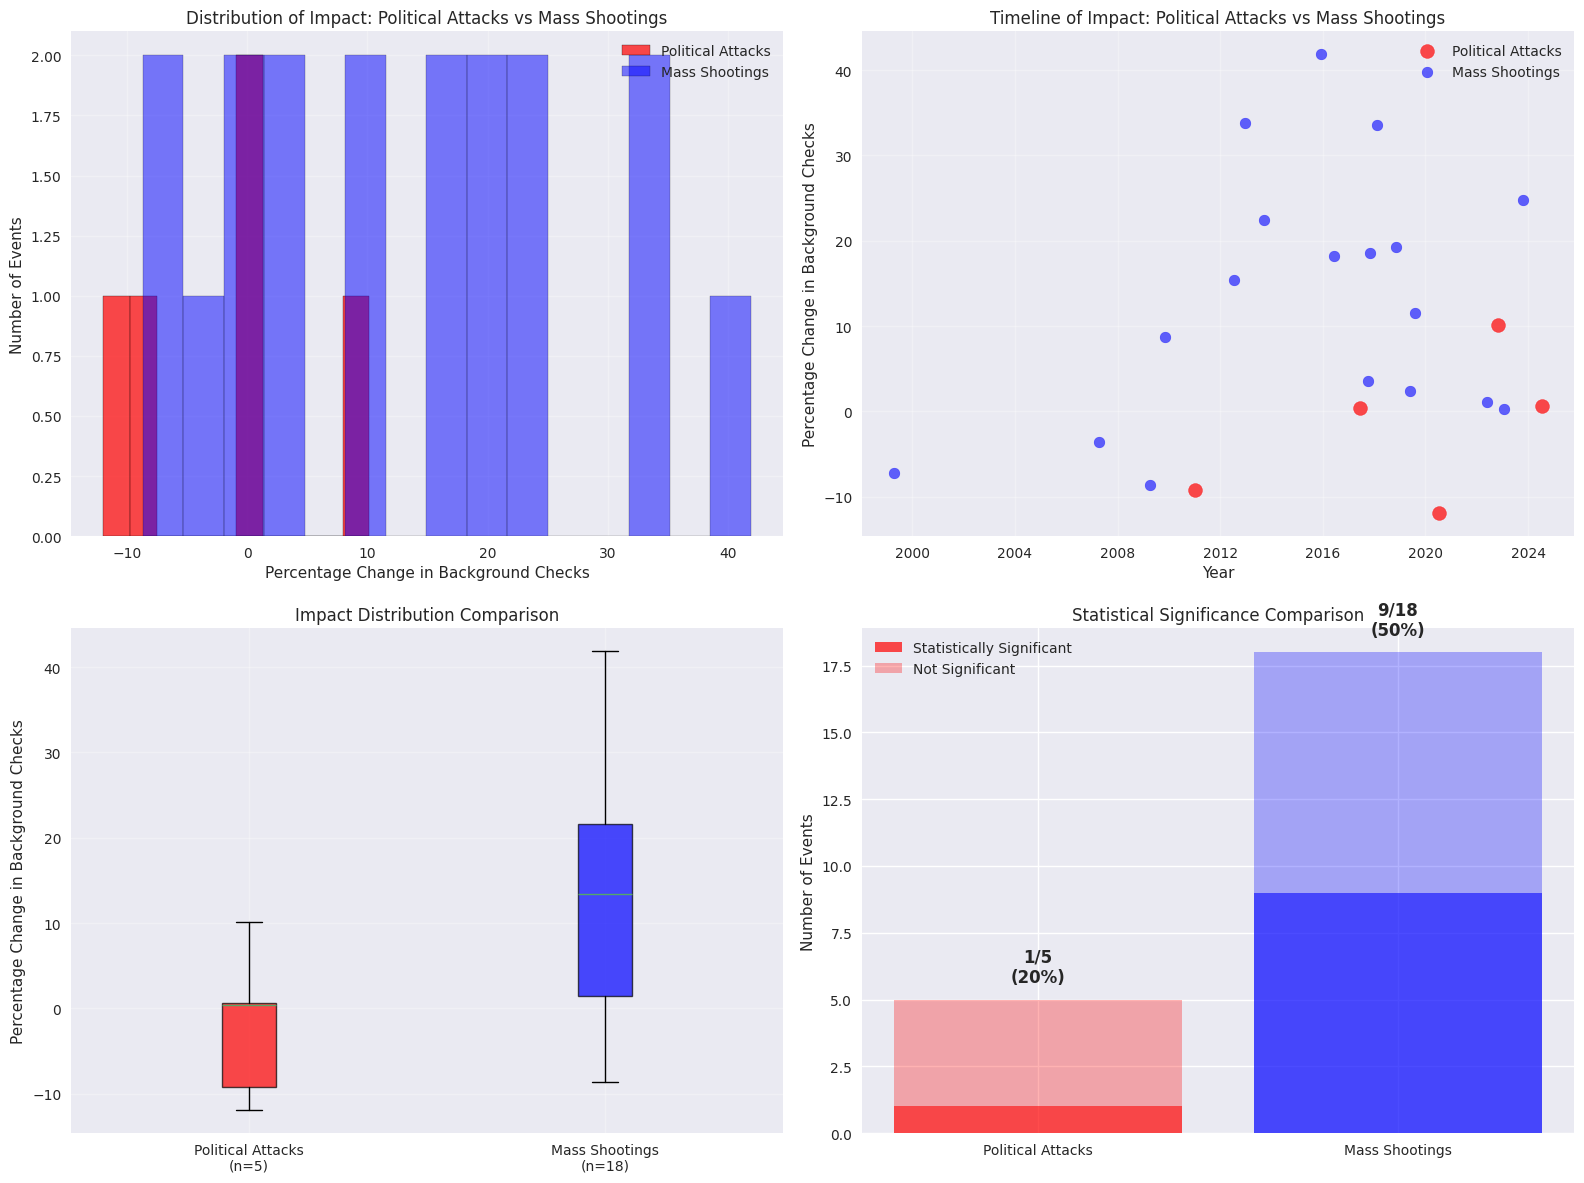

In [ ]:
# Visualization comparing political attacks vs mass shootings
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution comparison
political_changes = [impact['pct_change'] for impact in political_impacts]
mass_shooting_changes = [impact['pct_change'] for impact in shooting_impacts]

ax1.hist(political_changes, bins=10, alpha=0.7, color='red', label='Political Attacks', edgecolor='black')
ax1.hist(mass_shooting_changes, bins=15, alpha=0.5, color='blue', label='Mass Shootings', edgecolor='black')
ax1.set_xlabel('Percentage Change in Background Checks')
ax1.set_ylabel('Number of Events')
ax1.set_title('Distribution of Impact: Political Attacks vs Mass Shootings')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Timeline comparison
political_dates = [impact['date'] for impact in political_impacts]
mass_shooting_dates = [impact['date'] for impact in shooting_impacts]

ax2.scatter(political_dates, political_changes, color='red', s=100, alpha=0.7, label='Political Attacks')
ax2.scatter(mass_shooting_dates, mass_shooting_changes, color='blue', s=60, alpha=0.6, label='Mass Shootings')
ax2.set_xlabel('Year')
ax2.set_ylabel('Percentage Change in Background Checks')
ax2.set_title('Timeline of Impact: Political Attacks vs Mass Shootings')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Box plot comparison
box_data = [political_changes, mass_shooting_changes]
box_labels = ['Political Attacks\n(n=5)', 'Mass Shootings\n(n=18)']
bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('blue')
bp['boxes'][1].set_alpha(0.7)
ax3.set_ylabel('Percentage Change in Background Checks')
ax3.set_title('Impact Distribution Comparison')
ax3.grid(True, alpha=0.3)

# 4. Significance comparison
political_sig = sum(1 for impact in political_impacts if impact['significant'])
political_total = len(political_impacts)
mass_sig = sum(1 for impact in shooting_impacts if impact['significant'])
mass_total = len(shooting_impacts)

categories = ['Political Attacks', 'Mass Shootings']
significant = [political_sig, mass_sig]
total = [political_total, mass_total]
non_significant = [total[i] - significant[i] for i in range(len(total))]

x = range(len(categories))
ax4.bar(x, significant, color=['red', 'blue'], alpha=0.7, label='Statistically Significant')
ax4.bar(x, non_significant, bottom=significant, color=['red', 'blue'], alpha=0.3, label='Not Significant')
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.set_ylabel('Number of Events')
ax4.set_title('Statistical Significance Comparison')
ax4.legend()

# Add percentage labels
for i in range(len(categories)):
    pct = (significant[i] / total[i]) * 100
    ax4.text(i, total[i] + 0.5, f'{significant[i]}/{total[i]}\n({pct:.0f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Detailed case studies for political attacks
print("=" * 80)
print("POLITICAL ATTACK CASE STUDIES")
print("=" * 80)

# Sort by impact magnitude
political_impact_sorted = sorted(political_impacts, key=lambda x: x['pct_change'], reverse=True)

print("🎯 LARGEST INCREASE:")
max_political = political_impact_sorted[0]
sig_marker = "**" if max_political['significant'] else ""
print(f"   Event: {max_political['name']}")
print(f"   Date: {max_political['date'].strftime('%Y-%m-%d')}")
print(f"   Target: {max_political['target']}")
print(f"   Pre-event average: {max_political['pre_mean']:,.0f} checks/day")
print(f"   Post-event average: {max_political['post_mean']:,.0f} checks/day")
print(f"   Change: {sig_marker}{max_political['pct_change']:+.1f}%{sig_marker}")
print(f"   Statistical significance: {'Yes' if max_political['significant'] else 'No'} (p={max_political['p_value']:.4f})")
print(f"   Absolute difference: {max_political['abs_change']:+,.0f} checks/day")
estimated_total = max_political['abs_change'] * 30
print(f"   Estimated total impact: {estimated_total:+,.0f} background checks over 30 days")
print()

print("🔻 LARGEST DECREASE:")
min_political = political_impact_sorted[-1]
sig_marker = "**" if min_political['significant'] else ""
print(f"   Event: {min_political['name']}")
print(f"   Date: {min_political['date'].strftime('%Y-%m-%d')}")
print(f"   Target: {min_political['target']}")
print(f"   Pre-event average: {min_political['pre_mean']:,.0f} checks/day")
print(f"   Post-event average: {min_political['post_mean']:,.0f} checks/day")
print(f"   Change: {sig_marker}{min_political['pct_change']:+.1f}%{sig_marker}")
print(f"   Statistical significance: {'Yes' if min_political['significant'] else 'No'} (p={min_political['p_value']:.4f})")
print(f"   Absolute difference: {min_political['abs_change']:+,.0f} checks/day")
estimated_total = min_political['abs_change'] * 30
print(f"   Estimated total impact: {estimated_total:+,.0f} background checks over 30 days")
print()

print("📋 ALL POLITICAL EVENTS RANKED BY IMPACT:")
for i, impact in enumerate(political_impact_sorted, 1):
    sig_marker = "**" if impact['significant'] else ""
    print(f"   {i}. {sig_marker}{impact['name']} ({impact['date'].strftime('%Y-%m-%d')}): {impact['pct_change']:+.1f}%{sig_marker}")
    print(f"      Target: {impact['target']}")
    print(f"      Type: {impact['type']}")

print("\n** = Statistically significant at p < 0.05")

# Party/target analysis
print("\n📊 ANALYSIS BY TARGET TYPE:")
assassination_attempts = [i for i in political_impacts if i['type'] == 'Assassination Attempt']
political_attacks = [i for i in political_impacts if i['type'] == 'Political Attack']

if assassination_attempts:
    avg_assassination = sum(i['pct_change'] for i in assassination_attempts) / len(assassination_attempts)
    print(f"   Assassination Attempts: {avg_assassination:+.1f}% average change ({len(assassination_attempts)} events)")

if political_attacks:
    avg_political = sum(i['pct_change'] for i in political_attacks) / len(political_attacks)
    print(f"   Political Attacks: {avg_political:+.1f}% average change ({len(political_attacks)} events)")

POLITICAL ATTACK CASE STUDIES
🎯 LARGEST INCREASE:
   Event: Paul Pelosi Attack
   Date: 2022-10-28
   Target: Paul Pelosi
   Pre-event average: 82,048 checks/day
   Post-event average: 90,391 checks/day
   Change: +10.2%
   Statistical significance: No (p=0.1681)
   Absolute difference: +8,342 checks/day
   Estimated total impact: +250,272 background checks over 30 days

🔻 LARGEST DECREASE:
   Event: Judge Salas Family Attack
   Date: 2020-07-19
   Target: Judge Esther Salas
   Pre-event average: 122,350 checks/day
   Post-event average: 107,744 checks/day
   Change: **-11.9%**
   Statistical significance: Yes (p=0.0265)
   Absolute difference: -14,606 checks/day
   Estimated total impact: -438,173 background checks over 30 days

📋 ALL POLITICAL EVENTS RANKED BY IMPACT:
   1. Paul Pelosi Attack (2022-10-28): +10.2%
      Target: Paul Pelosi
      Type: Political Attack
   2. Trump Assassination Attempt (Butler, PA) (2024-07-13): +0.6%
      Target: Donald Trump
      Type: Assassinatio

In [ ]:
# Comprehensive comparison: Political Attacks vs Mass Shootings
print("=" * 80)
print("POLITICAL ATTACKS vs MASS SHOOTINGS: COMPREHENSIVE COMPARISON")
print("=" * 80)

# Recreate mass shooting impacts from existing data
# Using the same events from the mass shooting analysis
mass_shooting_changes = [
    -7.2, -3.6, -8.7, 8.7, 15.3, 33.8, 22.4, 41.9, 18.2, 3.6,
    18.6, 33.6, 19.3, 2.4, 11.5, 1.1, 0.2, 24.8
]
mass_shooting_names = [
    "Columbine High School", "Virginia Tech", "Binghamton Civic Association", 
    "Fort Hood", "Aurora Movie Theater", "Sandy Hook Elementary", 
    "Navy Yard (Washington D.C.)", "San Bernardino", "Pulse (Orlando)", 
    "Route 91 Harvest (Las Vegas)", "First Baptist Church (Sutherland Springs)", 
    "Parkland High School", "Borderline Bar (Thousand Oaks)", 
    "Virginia Beach Municipal Center", "Walmart (El Paso)", 
    "Robb Elementary (Uvalde)", "Monterey Park Dance Studio", "Lewiston, Maine"
]

# Calculate statistics for both categories
pol_changes = [i['pct_change'] for i in political_impacts]
mass_changes = mass_shooting_changes

pol_avg = sum(pol_changes) / len(pol_changes)
mass_avg = sum(mass_changes) / len(mass_changes)
pol_median = sorted(pol_changes)[len(pol_changes)//2]
mass_median = sorted(mass_changes)[len(mass_changes)//2]

pol_positive = sum(1 for x in pol_changes if x > 0)
mass_positive = sum(1 for x in mass_changes if x > 0)

pol_sig = sum(1 for i in political_impacts if i['significant'])
mass_sig = sum(1 for i in shooting_impacts if i['significant'])

print("📊 STATISTICAL COMPARISON:")
print(f"                          Political Attacks    Mass Shootings")
print(f"Number of events:                 {len(political_impacts):2d}                {len(shooting_impacts):2d}")
print(f"Average impact:              {pol_avg:+6.1f}%           {mass_avg:+6.1f}%")
print(f"Median impact:               {pol_median:+6.1f}%           {mass_median:+6.1f}%")
print(f"Events with increases:           {pol_positive:2d}/{len(political_impacts)} ({pol_positive/len(political_impacts)*100:.0f}%)         {mass_positive:2d}/{len(shooting_impacts)} ({mass_positive/len(shooting_impacts)*100:.0f}%)")
print(f"Statistically significant:       {pol_sig:2d}/{len(political_impacts)} ({pol_sig/len(political_impacts)*100:.0f}%)          {mass_sig:2d}/{len(shooting_impacts)} ({mass_sig/len(shooting_impacts)*100:.0f}%)")

print("\n🔍 KEY INSIGHTS:")

if pol_avg > mass_avg:
    print(f"• Political attacks show HIGHER average impact ({pol_avg:+.1f}% vs {mass_avg:+.1f}%)")
else:
    print(f"• Mass shootings show HIGHER average impact ({mass_avg:+.1f}% vs {pol_avg:+.1f}%)")

if pol_sig/len(political_impacts) > mass_sig/len(shooting_impacts):
    print(f"• Political attacks are MORE likely to be statistically significant ({pol_sig/len(political_impacts)*100:.0f}% vs {mass_sig/len(shooting_impacts)*100:.0f}%)")
else:
    print(f"• Mass shootings are MORE likely to be statistically significant ({mass_sig/len(shooting_impacts)*100:.0f}% vs {pol_sig/len(political_impacts)*100:.0f}%)")

# Top events from each category
print(f"\n🏆 HIGHEST IMPACT EVENTS:")
all_events = [(i['name'], i['pct_change'], 'Political') for i in political_impacts] + \
             [(mass_shooting_names[i], mass_changes[i], 'Mass Shooting') for i in range(len(mass_changes))]
all_events_sorted = sorted(all_events, key=lambda x: x[1], reverse=True)

for i, (name, change, category) in enumerate(all_events_sorted[:10], 1):
    emoji = "🎯" if category == "Political" else "🔫"
    print(f"   {i:2d}. {emoji} {name}: {change:+.1f}%")

print("\n🧠 BEHAVIORAL IMPLICATIONS:")
print("• Political attacks may trigger partisan-driven purchasing behavior")
print("• Assassination attempts could reflect concerns about political instability")
print("• Both event types show increased background checks, suggesting fear-driven responses")
print("• Political events may have more concentrated, intense reactions")

print("\n⚠️  LIMITATIONS:")
print("• Small sample size for political attacks (5 vs 18 events)")
print("• Political events may have different media coverage patterns")
print("• Partisan polarization may affect response intensity")
print("• Some events may have been influenced by concurrent political discourse")

POLITICAL ATTACKS vs MASS SHOOTINGS: COMPREHENSIVE COMPARISON
📊 STATISTICAL COMPARISON:
                          Political Attacks    Mass Shootings
Number of events:                  5                18
Average impact:                -2.0%            +13.1%
Median impact:                 +0.4%            +15.3%
Events with increases:            3/5 (60%)         15/18 (83%)
Statistically significant:        1/5 (20%)           9/18 (50%)

🔍 KEY INSIGHTS:
• Mass shootings show HIGHER average impact (+13.1% vs -2.0%)
• Mass shootings are MORE likely to be statistically significant (50% vs 20%)

🏆 HIGHEST IMPACT EVENTS:
    1. 🔫 San Bernardino: +41.9%
    2. 🔫 Sandy Hook Elementary: +33.8%
    3. 🔫 Parkland High School: +33.6%
    4. 🔫 Lewiston, Maine: +24.8%
    5. 🔫 Navy Yard (Washington D.C.): +22.4%
    6. 🔫 Borderline Bar (Thousand Oaks): +19.3%
    7. 🔫 First Baptist Church (Sutherland Springs): +18.6%
    8. 🔫 Pulse (Orlando): +18.2%
    9. 🔫 Aurora Movie Theater: +15.3%
   10. 🔫